<a href="https://colab.research.google.com/github/DVRTHVADER/Abdelahid2.0/blob/main/HEALTH_DISEASEProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HEALTH - DISEASE ML Project**

In [ ]:
#libraries and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
dataset_url ="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv(dataset_url, names=column_names, na_values='?')
print ("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df =df.dropna()
df ['target']=df['target'].apply(lambda x: 1 if x>0 else 0)
x = df.drop(columns=['target'])
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print ("Training Data Shape :", x_train_scaled.shape)
print ("Testing Data Shape :", x_test_scaled.shape)
print ("Training set size: {x_train.shape[0]} samples")
print ("Training set size: {x_test.shape[0]} samples")
df.head()

Training Data Shape : (237, 13)
Testing Data Shape : (60, 13)
Training set size: {x_train.shape[0]} samples
Training set size: {x_test.shape[0]} samples


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train_scaled, y_train)
print ("Model training complete")

Model training complete


Accuracy: 86.67%

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60


Confusion Matrix:
 [[29  3]
 [ 5 23]]


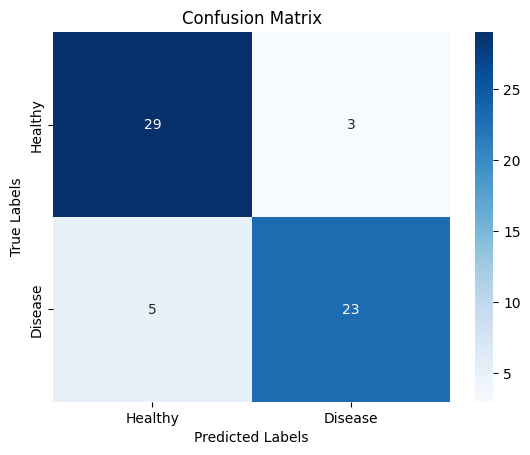

In [ ]:
y_pred = model.predict(x_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print ("Accuracy: {:.2f}%".format(accuracy * 100))
print ("\nClassification Report:\n", classification_report(y_test, y_pred))
print ("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Healthy','Disease'], yticklabels=['Healthy','Disease'])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
#

In [ ]:
#New data
new_patient = np.array([[63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]])
scaled_patient = scaler.transform(new_patient)
prediction = model.predict(scaled_patient)
probability = model.predict_proba(scaled_patient)
print ("Probability of Disease:", probability[0][1])
print ("Probability of Healthy:", probability[0][0])
if prediction[0] == 1:
    print ("The patient is predicted to have heart disease.")
else:
    print ("The patient is predicted to be healthy.")

print ("confidence score: {np.max(probability)*100:.1f}%")
print ("Prediction:", prediction)

Probability of Disease: 0.24
Probability of Healthy: 0.76
The patient is predicted to be healthy.
confidence score: {np.max(probability)*100:.1f}%
Prediction: [0]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
